<a href="https://colab.research.google.com/github/nevita275/ML_20_Nevita/blob/main/JS04/JS04-Tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TUGAS - REGRESI

## Langkah 0: Persiapan Data


In [1]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


## Langkah 1: Import Library

In [2]:
# import library dasar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# untuk preprocessing & modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

## Langkah 2: Baca dan Pahami Data

In [3]:
# baca data
data = pd.read_csv('insurance.csv')

# lihat data awal
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# ukuran data
data.shape

(1338, 7)

In [5]:
# info tipe data & missing value
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
# deskripsi statistik data numerik
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
# cek apakah ada missing value
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


## Langkah 3: Visualisasi Data (Eksplorasi)

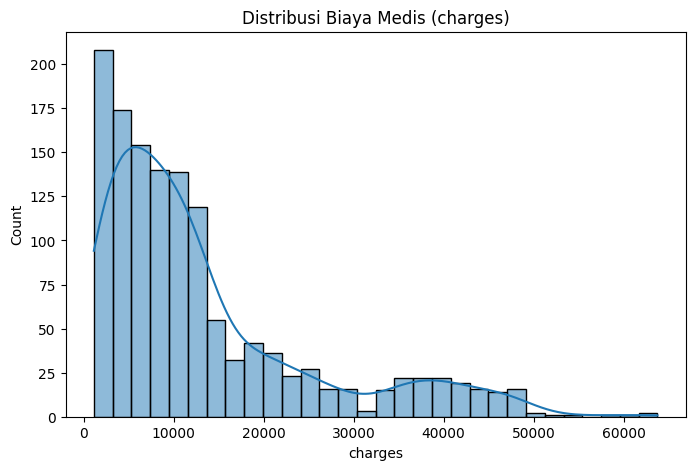

In [8]:
# distribusi variabel target
plt.figure(figsize=(8,5))
sns.histplot(data['charges'], bins=30, kde=True)
plt.title('Distribusi Biaya Medis (charges)')
plt.show()

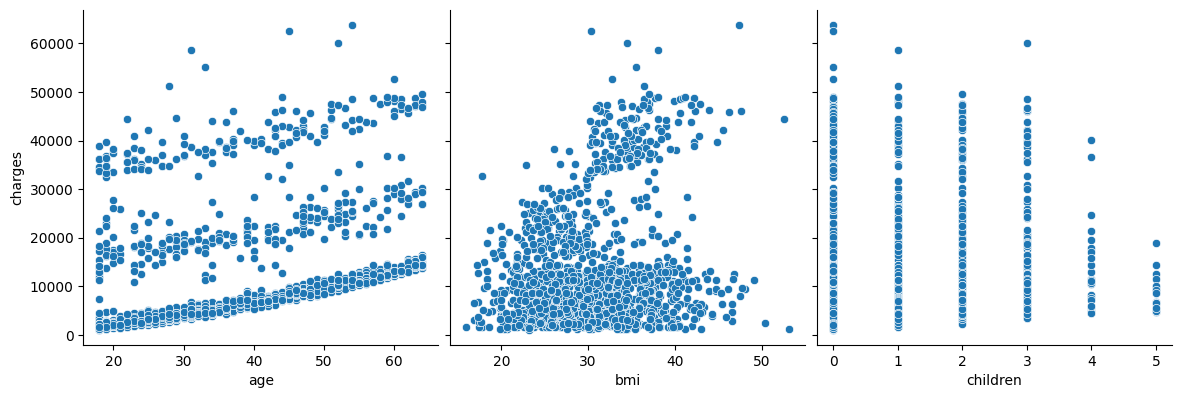

In [9]:
# hubungan antar variabel numerik terhadap charges
sns.pairplot(data, x_vars=['age', 'bmi', 'children'], y_vars='charges', height=4, kind='scatter')
plt.show()

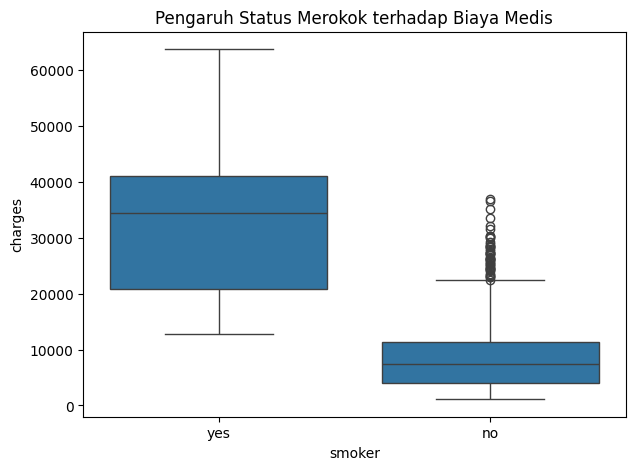

In [11]:
# pengaruh status merokok terhadap biaya
plt.figure(figsize=(7,5))
sns.boxplot(x='smoker', y='charges', data=data)
plt.title('Pengaruh Status Merokok terhadap Biaya Medis')
plt.show()

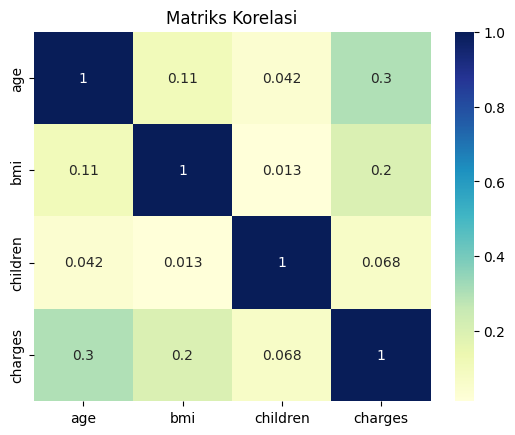

In [12]:
# heatmap korelasi antar variabel numerik
sns.heatmap(data.corr(numeric_only=True), cmap="YlGnBu", annot=True)
plt.title('Matriks Korelasi')
plt.show()

### 1. Identifikasi variabel-variabel yang akan digunakan sebagai variabel bebas (fitur) dan variabel target (biaya medis personal).

In [13]:
# encoding variabel kategorikal menjadi numerik
data_encoded = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True)
data_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


**Penjelasan: pd.get_dummies() mengubah setiap kategori menjadi kolom biner (0/1). Parameter drop_first=True digunakan untuk menghindari dummy variable trap (multikolinearitas), yaitu satu kategori dijadikan baseline/acuan.**

In [14]:
# pisahkan variabel bebas (X) dan target (y)
X = data_encoded.drop('charges', axis=1)
y = data_encoded['charges']

X.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False


### 2. Bagi dataset menjadi data latih (train) dan data uji (test) dengan proporsi yang sesuai.

In [15]:
# bagi data menjadi 80% data latih dan 20% data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Jumlah data latih:", X_train.shape[0])
print("Jumlah data uji  :", X_test.shape[0])

Jumlah data latih: 1070
Jumlah data uji  : 268


**Penjelasan: Proporsi 80:20 dipilih karena jumlah data (1338 baris) tergolong sedang, sehingga porsi data uji 20% sudah cukup representatif untuk evaluasi model.**

### 3. Lakukan feature scaling jika diperlukan.

In [16]:
# feature scaling menggunakan StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Penjelasan: Feature scaling wajib dilakukan terutama untuk model SVR, karena SVR sensitif terhadap skala data (menggunakan perhitungan jarak/kernel). Untuk Multiple Linear Regression, scaling sebenarnya tidak wajib secara matematis (koefisien tetap valid tanpa scaling), tapi tetap dilakukan di sini agar perbandingan kedua model konsisten dan adil.**

### 4. Buat model multiple linear regression menggunakan Scikit-Learn.

In [17]:
# membuat dan melatih model multiple linear regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# prediksi pada data uji
y_pred_lr = lr_model.predict(X_test_scaled)

In [18]:
# melihat koefisien tiap fitur
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': lr_model.coef_
}).sort_values(by='Koefisien', ascending=False)

coef_df

,Fitur,Koefisien
4,smoker_yes,9558.481409
0,age,3614.975415
1,bmi,2036.228123
2,children,516.890247
3,sex_male,-9.293101
5,region_northwest,-158.140981
6,region_southeast,-290.157047
7,region_southwest,-349.110678


**Penjelasannya: Dari hasil ini terlihat jelas bahwa status merokok adalah prediktor paling kuat terhadap tingginya biaya medis, jauh melebihi faktor lainnya bahkan hampir 2,5x lebih besar pengaruhnya dibanding usia (age), yang merupakan faktor terbesar kedua.**

### 5. Latih model pada data latih dan lakukan prediksi pada data uji.

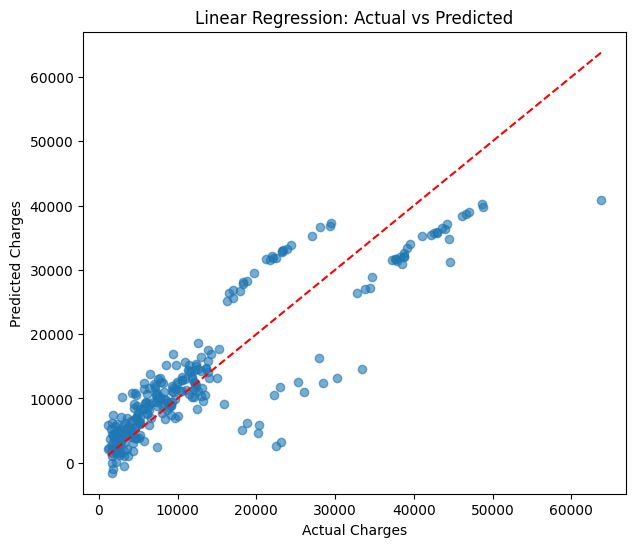

In [19]:
# visualisasi actual vs predicted
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()

### 6. Evaluasi model dengan menghitung metrik seperti R-squared, MSE, dan MAE. Tampilkan hasil evaluasi.

In [20]:
# evaluasi model Linear Regression
r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("=== Evaluasi Multiple Linear Regression ===")
print(f"R-squared : {r2_lr:.4f}")
print(f"MSE        : {mse_lr:.4f}")
print(f"MAE        : {mae_lr:.4f}")

=== Evaluasi Multiple Linear Regression ===
R-squared : 0.7836
MSE        : 33596915.8514
MAE        : 4181.1945


### 7. Ulagi langkah 4 dengan menggunakan model SVR. Anda dapat bereksperimen dengan dengan melakukan hyperparameter tunning.

In [21]:
# model SVR dasar (default) sebagai baseline
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train)

y_pred_svr = svr_model.predict(X_test_scaled)

# evaluasi SVR baseline
r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print("=== Evaluasi SVR (default, sebelum tuning) ===")
print(f"R-squared : {r2_svr:.4f}")
print(f"MSE        : {mse_svr:.4f}")
print(f"MAE        : {mae_svr:.4f}")

=== Evaluasi SVR (default, sebelum tuning) ===
R-squared : -0.0701
MSE        : 166128803.8085
MAE        : 8612.4084


In [22]:
# hyperparameter tuning menggunakan GridSearchCV
param_grid = {
    'C': [1, 10, 100, 1000],
    'gamma': ['scale', 0.01, 0.1],
    'epsilon': [0.1, 0.5, 1]
}

grid_search = GridSearchCV(
    estimator=SVR(kernel='rbf'),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Parameter terbaik:", grid_search.best_params_)

Parameter terbaik: {'C': 1000, 'epsilon': 0.1, 'gamma': 0.1}


In [23]:
# gunakan model SVR terbaik hasil tuning
best_svr = grid_search.best_estimator_
y_pred_svr_tuned = best_svr.predict(X_test_scaled)

# evaluasi SVR setelah tuning
r2_svr_tuned = r2_score(y_test, y_pred_svr_tuned)
mse_svr_tuned = mean_squared_error(y_test, y_pred_svr_tuned)
mae_svr_tuned = mean_absolute_error(y_test, y_pred_svr_tuned)

print("=== Evaluasi SVR (setelah tuning) ===")
print(f"R-squared : {r2_svr_tuned:.4f}")
print(f"MSE        : {mse_svr_tuned:.4f}")
print(f"MAE        : {mae_svr_tuned:.4f}")

=== Evaluasi SVR (setelah tuning) ===
R-squared : 0.7581
MSE        : 37552031.8405
MAE        : 2736.5890


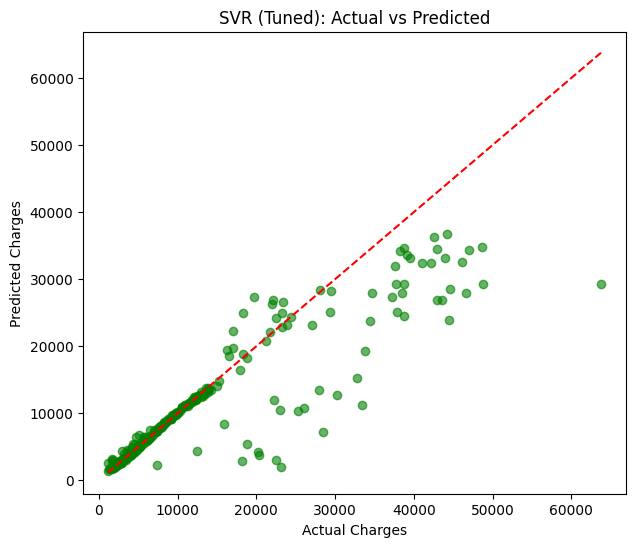

In [24]:
# visualisasi actual vs predicted untuk SVR tuned
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_svr_tuned, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('SVR (Tuned): Actual vs Predicted')
plt.show()

## Perbandingan Kedua Model

In [25]:
# tabel perbandingan hasil evaluasi
comparison = pd.DataFrame({
    'Model': ['Multiple Linear Regression', 'SVR (default)', 'SVR (tuned)'],
    'R-squared': [r2_lr, r2_svr, r2_svr_tuned],
    'MSE': [mse_lr, mse_svr, mse_svr_tuned],
    'MAE': [mae_lr, mae_svr, mae_svr_tuned]
})

comparison

,Model,R-squared,MSE,MAE
0,Multiple Linear Regression,0.783593,3.359692e+07,4181.194474
1,SVR (default),-0.070082,1.661288e+08,8612.408423
2,SVR (tuned),0.758117,3.755203e+07,2736.589013


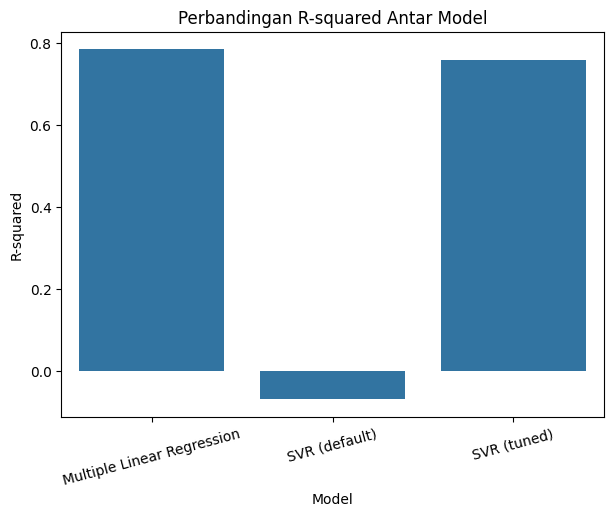

In [26]:
# visualisasi perbandingan R-squared antar model
plt.figure(figsize=(7,5))
sns.barplot(x='Model', y='R-squared', data=comparison)
plt.title('Perbandingan R-squared Antar Model')
plt.xticks(rotation=15)
plt.show()

**Penjelasannya:**<br>
**1. Variabel paling berpengaruh terhadap biaya medis adalah status merokok (smoker), diikuti oleh usia (age) dan BMI, sesuai koefisien Linear Regression yang diperoleh sebelumnya.**<br>
**2. SVR default sangat buruk (R² negatif, -0.07) karena parameter belum disesuaikan bahkan lebih buruk daripada sekadar menebak nilai rata-rata. Ini menunjukkan SVR sangat bergantung pada pemilihan hyperparameter yang tepat.** <br>
**3. Setelah hyperparameter tuning (C=1000, gamma=0.1, epsilon=0.1), performa SVR melonjak drastis dari R² -0.07 menjadi 0.7581, hampir menyamai Linear Regression (0.7836) terlihat jelas pada grafik batang perbandingan.** <br>
**4. Linear Regression sedikit unggul di R² dan MSE, artinya secara keseluruhan model ini sedikit lebih baik menjelaskan variasi data dan lebih tahan terhadap outlier/error besar.** <br>
**5. SVR justru unggul di MAE (2736.59 vs 4181.19), artinya rata-rata kesalahan prediksi per data SVR tuned lebih kecil dan lebih konsisten untuk mayoritas kasus, meski kurang baik menangani kasus ekstrem (outlier) dibanding Linear Regression.** <br><br>

**Kesimpulan: Kedua model memiliki performa yang sebanding setelah SVR dituning. Linear Regression lebih baik jika prioritasnya adalah kemudahan interpretasi (mengetahui kontribusi tiap fitur) dan ketahanan terhadap outlier. SVR lebih baik jika prioritasnya adalah akurasi prediksi rata-rata yang lebih presisi pada kasus umum. Hasil ini juga menegaskan bahwa hyperparameter tuning adalah langkah krusial dalam penggunaan SVR tanpa tuning, performanya bisa sangat buruk.**